In [1]:
#!/usr/bin/env python3
"""
==============================================================================
HAOR FLOOD ANALYSIS — OFFLINE VISUALIZATION NOTEBOOK (v2)
==============================================================================
Reads exported GeoTIFFs + BWDB waterbodies shapefile and renders matplotlib
maps with toggleable layers.

NEW IN v2:
  - BWDB waterbodies shapefile overlay (named haors highlighted)
  - Master settings panel at the END of the notebook
    → Re-run just that cell to change which layers are visible
    → No need to reload data each time you change settings

Required files in DATA_DIR:
  GeoTIFFs (from haor_export_data.py):
    - first_wet_date.tif, total_wet_count.tif, wet_fraction.tif
    - hand.tif, hand_classes.tif, river_network.tif
    - haor_boundaries.tif, jrc_water_occurrence.tif
    - fabdem_elevation.tif, fabdem_relative_elev.tif, fabdem_slope.tif
    - fabdem_local_relief.tif, barrier_high_conf.tif, barrier_any_conf.tif
    - fabdem_barriers.tif, hand_barriers.tif
  CSVs:
    - per_haor_area_timeseries_2025.csv
    - total_flood_area_timeseries_2025.csv
  BWDB Waterbodies (extracted from Waterbodies.rar):
    - Waterbodies/Waterbodiesdeg.shp (+ .dbf, .shx, .prj, etc.)

Install: pip install rasterio matplotlib numpy pandas geopandas shapely scipy
==============================================================================
"""

# %%
# =============================================================================
# CELL 1: IMPORTS
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch

try:
    import rasterio
except ImportError:
    print("rasterio not installed. Run: pip install rasterio --break-system-packages")
    raise

try:
    import pandas as pd
except ImportError:
    print("pandas not installed. Run: pip install pandas --break-system-packages")
    raise

try:
    import geopandas as gpd
    from shapely.geometry import box
except ImportError:
    print("geopandas not installed. Run: pip install geopandas --break-system-packages")
    raise

from scipy import ndimage

print("✓ Imports successful")


✓ Imports successful


In [2]:
# %%
# =============================================================================
# CELL 2: DATA PATHS AND CONSTANTS
# =============================================================================

DATA_DIR = "/work/a06/wasif/haor_flood_analysis"

# BWDB waterbodies shapefile (after extracting Waterbodies.rar)
# If you haven't extracted yet, run:
#   cd /work/a06/wasif/haor_flood_analysis && unrar x Waterbodies.rar
WATERBODIES_SHP = os.path.join(DATA_DIR, "Waterbodies", "Waterbodiesdeg.shp")

# Output directory for saved figures
FIG_DIR = os.path.join(DATA_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Haor AOI bounding box
HAOR_BBOX = [89.8, 23.5, 92.8, 25.5]  # [west, south, east, north]

print(f"Data directory: {DATA_DIR}")
print(f"Figure directory: {FIG_DIR}")

Data directory: /work/a06/wasif/haor_flood_analysis
Figure directory: /work/a06/wasif/haor_flood_analysis/figures


In [3]:
# %%
# =============================================================================
# CELL 3: LOAD ALL GEOTIFFS (run once, cache in memory)
# =============================================================================

def load_tif(filename):
    """Load a GeoTIFF and return data array + extent for matplotlib."""
    filepath = os.path.join(DATA_DIR, filename)
    if not os.path.exists(filepath):
        print(f"  ⚠ File not found: {filepath}")
        return None, None
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]
        return data, extent

print("Loading GeoTIFFs...")
layers = {}

file_map = {
    "first_wet_date": "first_wet_date.tif",
    "total_wet_count": "total_wet_count.tif",
    "wet_fraction": "wet_fraction.tif",
    "hand": "hand.tif",
    "hand_classes": "hand_classes.tif",
    "fabdem_elevation": "fabdem_elevation.tif",
    "fabdem_relative_elev": "fabdem_relative_elev.tif",
    "fabdem_local_relief": "fabdem_local_relief.tif",
    "barrier_high_conf": "barrier_high_conf.tif",
    "barrier_any_conf": "barrier_any_conf.tif",
    "fabdem_barriers": "fabdem_barriers.tif",
    "hand_barriers": "hand_barriers.tif",
    "river_network": "river_network.tif",
    "haor_boundaries": "haor_boundaries.tif",
    "jrc_water_occurrence": "jrc_water_occurrence.tif",
}

for name, filename in file_map.items():
    data, extent = load_tif(filename)
    if data is not None:
        layers[name] = {"data": data, "extent": extent}
        valid = data[~np.isnan(data)]
        if len(valid) > 0:
            print(f"  ✓ {name}: shape={data.shape}, "
                  f"range=[{valid.min():.2f}, {valid.max():.2f}]")
        else:
            print(f"  ✓ {name}: shape={data.shape} (all NaN)")

print(f"\n✓ Loaded {len(layers)} GeoTIFF layers")
default_extent = list(layers.values())[0]["extent"] if layers else HAOR_BBOX


Loading GeoTIFFs...
  ✓ first_wet_date: shape=(2235, 3341), range=[90.50, 270.50]
  ✓ total_wet_count: shape=(2235, 3341), range=[0.00, 54.00]
  ✓ wet_fraction: shape=(2235, 3341), range=[0.00, 1.00]
  ✓ hand: shape=(2235, 3341), range=[0.00, 1138.40]
  ✓ hand_classes: shape=(2235, 3341), range=[0.00, 4.00]
  ✓ fabdem_elevation: shape=(7450, 11133), range=[-9.12, 1936.85]
  ✓ fabdem_relative_elev: shape=(7450, 11133), range=[0.00, 486.77]
  ✓ fabdem_local_relief: shape=(7450, 11133), range=[-130.63, 98.73]
  ✓ barrier_high_conf: shape=(7450, 11133), range=[0.00, 1.00]
  ✓ barrier_any_conf: shape=(7450, 11133), range=[0.00, 1.00]
  ✓ fabdem_barriers: shape=(7450, 11133), range=[0.00, 1.00]
  ✓ hand_barriers: shape=(2235, 3341), range=[0.00, 1.00]
  ✓ river_network: shape=(2235, 3341), range=[0.00, 1.00]
  ✓ haor_boundaries: shape=(2235, 3341), range=[0.00, 12135.00]
  ✓ jrc_water_occurrence: shape=(2235, 3341), range=[0.00, 100.00]

✓ Loaded 15 GeoTIFF layers


Full raster shape: (2235, 3341)
Full raster extent [W,E,S,N]: [89.79918906172385, 92.80046042596717, 23.499927832566684, 25.507662492573814]

Crop indices: rows [286:732], cols [1169:1893]
Crop covers 446 rows x 724 cols = 322,904 pixels (before NaN filter)
Crop is 4.3% of full raster


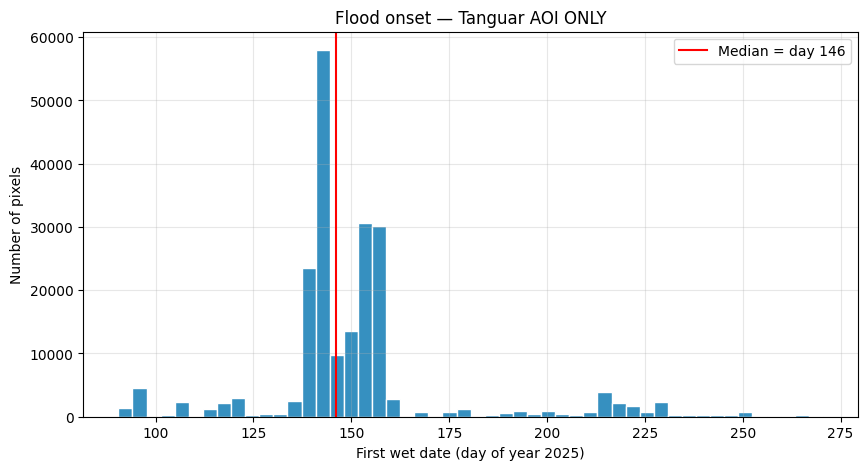


Pixels analyzed (after NaN filter): 208,361
10th pct: day 138
Median:   day 146
90th pct: day 168
Inter-decile range: 29 days


In [11]:
# %%
# CELL 3b — Tanguar diagnostic WITH verification
import numpy as np
import matplotlib.pyplot as plt

fwd = layers["first_wet_date"]["data"]
ext = layers["first_wet_date"]["extent"]   # matplotlib order: [W, E, S, N]

print(f"Full raster shape: {fwd.shape}")
print(f"Full raster extent [W,E,S,N]: {ext}")

# Tanguar box in [W, E, S, N] order to MATCH the extent convention
TANGUAR_W, TANGUAR_E = 90.85, 91.50
TANGUAR_S, TANGUAR_N = 24.85, 25.25

nrows, ncols = fwd.shape
W, E, S, N = ext[0], ext[1], ext[2], ext[3]

# Column index increases with longitude (left to right = W to E)
col_min = int((TANGUAR_W - W) / (E - W) * ncols)
col_max = int((TANGUAR_E - W) / (E - W) * ncols)
# Row index increases downward; row 0 = North edge
row_min = int((N - TANGUAR_N) / (N - S) * nrows)
row_max = int((N - TANGUAR_S) / (N - S) * nrows)

print(f"\nCrop indices: rows [{row_min}:{row_max}], cols [{col_min}:{col_max}]")
print(f"Crop covers {row_max-row_min} rows x {col_max-col_min} cols "
      f"= {(row_max-row_min)*(col_max-col_min):,} pixels (before NaN filter)")

# Sanity: this should be MUCH smaller than the full raster
full_px = nrows * ncols
crop_px = (row_max - row_min) * (col_max - col_min)
print(f"Crop is {100*crop_px/full_px:.1f}% of full raster")

fwd_crop = fwd[row_min:row_max, col_min:col_max]
valid = fwd_crop[~np.isnan(fwd_crop) & (fwd_crop > 0)]

plt.figure(figsize=(10, 5))
plt.hist(valid, bins=50, color="#3690c0", edgecolor="white")
plt.axvline(np.median(valid), color="red", label=f"Median = day {np.median(valid):.0f}")
plt.xlabel("First wet date (day of year 2025)")
plt.ylabel("Number of pixels")
plt.title("Flood onset — Tanguar AOI ONLY")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"\nPixels analyzed (after NaN filter): {len(valid):,}")
print(f"10th pct: day {np.percentile(valid,10):.0f}")
print(f"Median:   day {np.median(valid):.0f}")
print(f"90th pct: day {np.percentile(valid,90):.0f}")
print(f"Inter-decile range: {np.percentile(valid,90)-np.percentile(valid,10):.0f} days")

In [4]:
# %%
# =============================================================================
# CELL 4: LOAD BWDB WATERBODIES SHAPEFILE
# =============================================================================

bwdb_haors = None
bwdb_all = None

if os.path.exists(WATERBODIES_SHP):
    print(f"Loading BWDB waterbodies shapefile...")
    bwdb_all = gpd.read_file(WATERBODIES_SHP)

    # Filter to haor AOI
    haor_bbox = box(*HAOR_BBOX)
    bwdb_haors = bwdb_all[bwdb_all.intersects(haor_bbox)].copy()

    print(f"✓ BWDB waterbodies loaded")
    print(f"  Total in Bangladesh: {len(bwdb_all)}")
    print(f"  In haor AOI: {len(bwdb_haors)}")
    print(f"  Named: {bwdb_haors['WBNAME'].notna().sum()}")

    haors_only = bwdb_haors[bwdb_haors["WBNAME"].str.contains("aor", case=False, na=False)]
    beels_only = bwdb_haors[bwdb_haors["WBNAME"].str.contains("eel", case=False, na=False)]
    print(f"  Named 'Haor': {len(haors_only)}")
    print(f"  Named 'Beel': {len(beels_only)}")
else:
    print(f"⚠ Waterbodies shapefile not found at {WATERBODIES_SHP}")
    print("  If you haven't extracted yet, run:")
    print(f"    cd {DATA_DIR} && unrar x Waterbodies.rar")


Loading BWDB waterbodies shapefile...
✓ BWDB waterbodies loaded
  Total in Bangladesh: 13096
  In haor AOI: 6686
  Named: 1185
  Named 'Haor': 49
  Named 'Beel': 1132


In [5]:
# %%
# =============================================================================
# CELL 5: LOAD TIME SERIES CSV FILES
# =============================================================================

df_total = None
df_per_haor = None

csv_total = os.path.join(DATA_DIR, "total_flood_area_timeseries_2025.csv")
csv_per_haor = os.path.join(DATA_DIR, "per_haor_area_timeseries_2025.csv")

if os.path.exists(csv_total):
    df_total = pd.read_csv(csv_total)
    df_total["date"] = pd.to_datetime(df_total["date"])
    print(f"✓ Total area time series: {len(df_total)} dates")
else:
    print(f"⚠ Not found: {csv_total}")

if os.path.exists(csv_per_haor):
    df_per_haor = pd.read_csv(csv_per_haor)
    print(f"✓ Per-haor time series: {len(df_per_haor)} haors")
else:
    print(f"⚠ Not found: {csv_per_haor}")

✓ Total area time series: 31 dates
✓ Per-haor time series: 1345 haors


In [6]:
# %%
# =============================================================================
# CELL 6: COLOR MAPS
# =============================================================================

# First-wet-date: smooth 24-color gradient
fwd_colors = [
    "#023858", "#045a8d", "#0570b0", "#3690c0",
    "#74a9cf", "#66c2a4", "#41ae76", "#238b45",
    "#006d2c", "#31a354", "#78c679", "#addd8e",
    "#d9f0a3", "#f7fcb1", "#ffeda0", "#fed976",
    "#feb24c", "#fd8d3c", "#fc4e2a", "#e31a1c",
    "#d7301f", "#bd0026", "#a50026", "#800026",
]
cmap_fwd = mcolors.LinearSegmentedColormap.from_list("first_wet", fwd_colors, N=256)
cmap_fwd.set_bad(alpha=0)

cmap_hand = plt.cm.plasma.copy(); cmap_hand.set_bad(alpha=0)
cmap_relief = plt.cm.RdBu_r.copy(); cmap_relief.set_bad(alpha=0)
cmap_elev = plt.cm.terrain.copy(); cmap_elev.set_bad(alpha=0)
cmap_jrc = mcolors.LinearSegmentedColormap.from_list("jrc", ["#FFFFFF", "#0000FF"], N=256)
cmap_jrc.set_bad(alpha=0)
cmap_handcls = mcolors.ListedColormap(["#2166AC", "#92C5DE", "#F4A582", "#B2182B"])

print("✓ Colormaps defined")


✓ Colormaps defined


In [7]:
# %%
# =============================================================================
# CELL 7: PLOTTING FUNCTIONS
# =============================================================================

def plot_raster_layer(ax, layer_name, cmap, vmin, vmax, alpha=0.7,
                      mask_below=None, mask_zero=False):
    """Plot a raster layer on the given axis."""
    if layer_name not in layers:
        return False
    d = layers[layer_name]
    data = d["data"].copy()
    if mask_below is not None:
        data[data < mask_below] = np.nan
    if mask_zero:
        data[data == 0] = np.nan
    ax.imshow(data, extent=d["extent"], cmap=cmap, vmin=vmin, vmax=vmax,
              alpha=alpha, origin="upper", aspect="auto", interpolation="nearest")
    return True


def plot_binary_overlay(ax, layer_name, color, alpha=0.6, marker_size=0.2,
                       subsample=50000):
    """Plot binary 0/1 raster as scatter points (more visible than imshow)."""
    if layer_name not in layers:
        return False
    d = layers[layer_name]
    rows, cols = np.where(d["data"] > 0)
    if len(rows) == 0:
        return False
    ext = d["extent"]
    lons = ext[0] + (cols + 0.5) * (ext[1] - ext[0]) / d["data"].shape[1]
    lats = ext[3] - (rows + 0.5) * (ext[3] - ext[2]) / d["data"].shape[0]
    if len(rows) > subsample:
        idx = np.random.choice(len(rows), subsample, replace=False)
        lons, lats = lons[idx], lats[idx]
    ax.scatter(lons, lats, s=marker_size, c=color, alpha=alpha, rasterized=True)
    return True


def plot_haor_outlines(ax, layer_name, color="#00FF00", alpha=0.8):
    """Plot haor boundaries as edges."""
    if layer_name not in layers:
        return False
    d = layers[layer_name]
    data = d["data"]
    valid = ~np.isnan(data) & (data > 0)
    edges = ndimage.binary_dilation(valid) & ~valid
    rows, cols = np.where(edges)
    if len(rows) == 0:
        return False
    ext = d["extent"]
    lons = ext[0] + (cols + 0.5) * (ext[1] - ext[0]) / data.shape[1]
    lats = ext[3] - (rows + 0.5) * (ext[3] - ext[2]) / data.shape[0]
    ax.scatter(lons, lats, s=0.3, c=color, alpha=alpha, rasterized=True)
    return True


def plot_bwdb_waterbodies(ax, show_all=True, show_haors=True, show_beels=False,
                          label_largest=0, all_color="#00CED1", haor_color="#00FF00",
                          beel_color="#FFA500", all_lw=0.3, haor_lw=1.0, beel_lw=0.5):
    """Plot BWDB waterbodies overlay with various options."""
    if bwdb_haors is None:
        return []
    added = []
    if show_all:
        bwdb_haors.boundary.plot(ax=ax, color=all_color, linewidth=all_lw, alpha=0.5)
        added.append(("BWDB all waterbodies", all_color))
    if show_haors:
        haors_named = bwdb_haors[bwdb_haors["WBNAME"].str.contains("aor", case=False, na=False)]
        if len(haors_named) > 0:
            haors_named.boundary.plot(ax=ax, color=haor_color, linewidth=haor_lw, alpha=0.9)
            added.append((f"Named Haors ({len(haors_named)})", haor_color))
    if show_beels:
        beels = bwdb_haors[bwdb_haors["WBNAME"].str.contains("eel", case=False, na=False)]
        if len(beels) > 0:
            beels.boundary.plot(ax=ax, color=beel_color, linewidth=beel_lw, alpha=0.7)
            added.append((f"Named Beels ({len(beels)})", beel_color))
    if label_largest > 0:
        named = bwdb_haors[bwdb_haors["WBNAME"].notna() & (bwdb_haors["WBNAME"] != "")]
        largest = named.nlargest(label_largest, "AREA_SQKM")
        for _, row in largest.iterrows():
            centroid = row.geometry.centroid
            txt = ax.annotate(row["WBNAME"], xy=(centroid.x, centroid.y),
                              fontsize=6, color="white", ha="center", fontweight="bold")
            txt.set_path_effects([
                path_effects.withStroke(linewidth=2, foreground="black")
            ])
    return added


def apply_extent(ax, extent_override, default_extent):
    """Apply zoom extent."""
    ext = extent_override if extent_override is not None else default_extent
    if extent_override is not None:
        ax.set_xlim(extent_override[0], extent_override[1])
        ax.set_ylim(extent_override[2], extent_override[3])
    else:
        ax.set_xlim(default_extent[0], default_extent[1])
        ax.set_ylim(default_extent[2], default_extent[3])


def setup_axis(ax, title):
    """Standard axis formatting."""
    ax.grid(True, linestyle="--", alpha=0.3, color="gray")
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°N)", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold")


print("✓ Plotting functions defined")

✓ Plotting functions defined


✓ Saved: /work/a06/wasif/haor_flood_analysis/figures/plot_total_flood_area.png


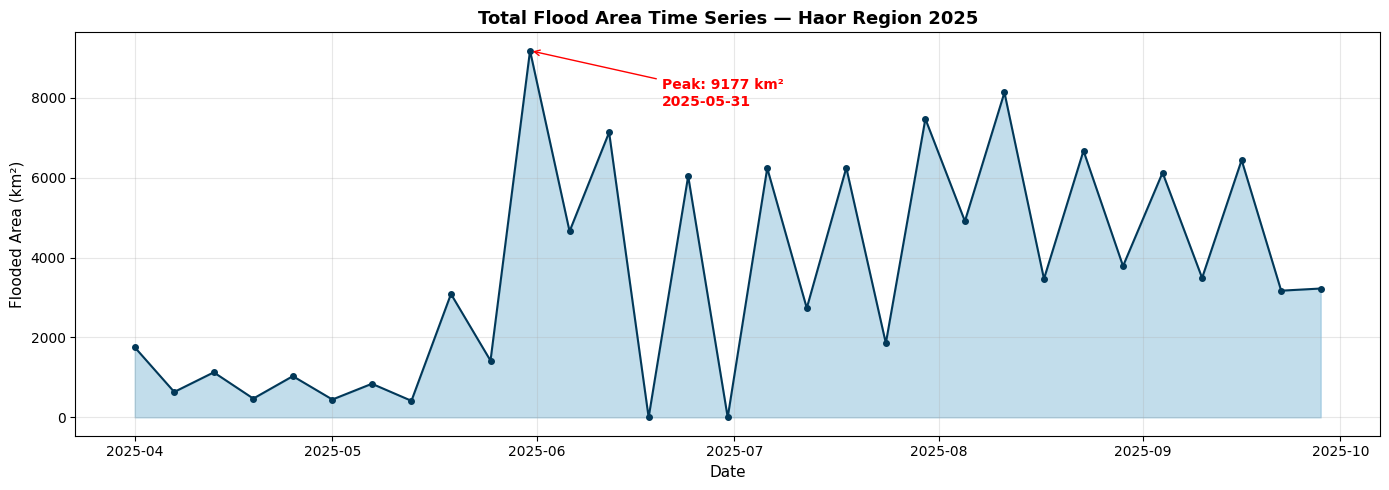

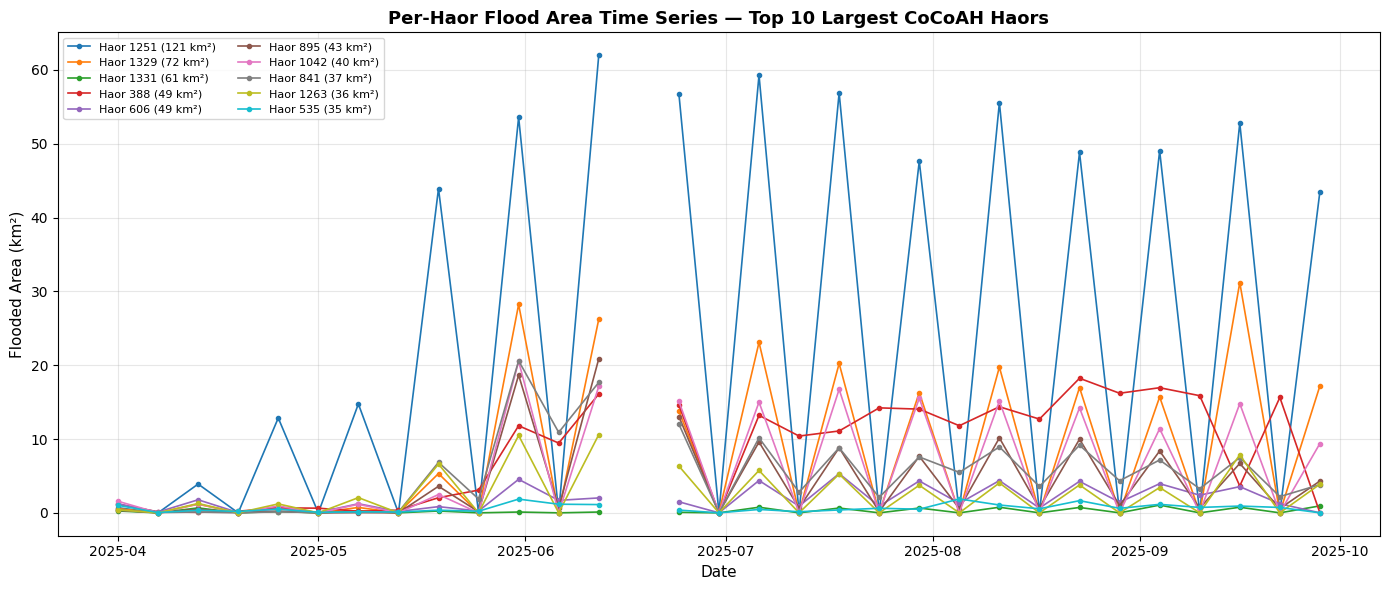

In [8]:
# %%
# =============================================================================
# CELL 8: TIME SERIES PLOTS (independent of layer toggling)
# =============================================================================

# Total area time series
if df_total is not None:
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    ax.fill_between(df_total["date"], df_total["area_km2"], alpha=0.3, color="#3690c0")
    ax.plot(df_total["date"], df_total["area_km2"], "o-",
            color="#023858", markersize=4, linewidth=1.5)
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Flooded Area (km²)", fontsize=11)
    ax.set_title("Total Flood Area Time Series — Haor Region 2025",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)

    valid_total = df_total[df_total["area_km2"] > 0]
    if len(valid_total) > 0:
        peak_idx = valid_total["area_km2"].idxmax()
        peak_date = df_total.loc[peak_idx, "date"]
        peak_area = df_total.loc[peak_idx, "area_km2"]
        ax.annotate(f"Peak: {peak_area:.0f} km²\n{peak_date.strftime('%Y-%m-%d')}",
                    xy=(peak_date, peak_area),
                    xytext=(peak_date + pd.Timedelta(days=20), peak_area * 0.85),
                    arrowprops=dict(arrowstyle="->", color="red"),
                    fontsize=10, color="red", fontweight="bold")
    plt.tight_layout()
    save_path = os.path.join(FIG_DIR, "plot_total_flood_area.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"✓ Saved: {save_path}")
    plt.show()

# Per-haor area time series (top 10)
if df_per_haor is not None:
    df_valid = df_per_haor[df_per_haor["total_area_km2"] > 0].copy()
    df_top = df_valid.nlargest(10, "total_area_km2")
    date_cols = [c for c in df_per_haor.columns if c.startswith("2025")]

    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    for _, row in df_top.iterrows():
        dates = pd.to_datetime(date_cols)
        areas = row[date_cols].values.astype(float)
        # Replace error values (-1) with NaN
        areas = np.where(areas < 0, np.nan, areas)
        label = f"Haor {int(row['haor_idx'])} ({row['total_area_km2']:.0f} km²)"
        ax.plot(dates, areas, "o-", markersize=3, linewidth=1.2, label=label)
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Flooded Area (km²)", fontsize=11)
    ax.set_title("Per-Haor Flood Area Time Series — Top 10 Largest CoCoAH Haors",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # save_path = os.path.join(FIG_DIR, "plot_per_haor_area.png")
    # plt.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
    # print(f"✓ Saved: {save_path}")
    # plt.show()

In [9]:
# %%
# =============================================================================
# CELL 9: MAIN MAP RENDERING FUNCTION
# =============================================================================
# This is the master plotting function. The settings panel below calls this
# with different parameters to produce different views.

def render_map(settings):
    """
    Render a composite map according to settings dict.
    Settings dict should contain all toggle/parameter values.
    """
    fig, ax = plt.subplots(1, 1, figsize=settings["figsize"])
    legend_elements = []

    # ---- Background raster layers (drawn first, in order) ----

    # 1. First Wet Date (typically the main background)
    if settings["show_first_wet_date"]:
        if plot_raster_layer(ax, "first_wet_date", cmap_fwd, 90, 272,
                             alpha=settings["alpha_first_wet_date"],
                             mask_below=0):
            d = layers["first_wet_date"]
            sm = plt.cm.ScalarMappable(cmap=cmap_fwd,
                                       norm=mcolors.Normalize(vmin=90, vmax=272))
            sm.set_array([])
            plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02,
                         label="First Wet Date (day of year 2025)")
            legend_elements.append(Patch(facecolor="#3690c0", label="First Wet Date"))

    # 2. HAND
    if settings["show_hand"]:
        if plot_raster_layer(ax, "hand", cmap_hand, 0, 10,
                             alpha=settings["alpha_hand"], mask_below=0):
            legend_elements.append(Patch(facecolor="#FBB32F", label="HAND (m)"))

    # 3. HAND classes
    if settings["show_hand_classes"]:
        if plot_raster_layer(ax, "hand_classes", cmap_handcls, 1, 4,
                             alpha=settings["alpha_hand_classes"], mask_below=1):
            legend_elements.append(Patch(facecolor="#2166AC", label="HAND <1m (haor)"))
            legend_elements.append(Patch(facecolor="#B2182B", label="HAND >6m (upland)"))

    # 4. FABDEM local relief
    if settings["show_fabdem_relief"]:
        if plot_raster_layer(ax, "fabdem_local_relief", cmap_relief, -1, 2,
                             alpha=settings["alpha_fabdem_relief"]):
            legend_elements.append(Patch(facecolor="#CA0020", label="FABDEM relief (+)"))

    # 5. FABDEM elevation
    if settings["show_fabdem_elev"]:
        if plot_raster_layer(ax, "fabdem_elevation", cmap_elev, 0, 30,
                             alpha=settings["alpha_fabdem_elev"]):
            legend_elements.append(Patch(facecolor="#FB9B06", label="FABDEM elev."))

    # 6. JRC water occurrence
    if settings["show_jrc_water"]:
        if plot_raster_layer(ax, "jrc_water_occurrence", cmap_jrc, 0, 100,
                             alpha=settings["alpha_jrc_water"], mask_zero=True):
            legend_elements.append(Patch(facecolor="#0000FF", label="JRC water occur."))

    # ---- Binary overlays (scatter points) ----

    # 7. High-confidence barriers
    if settings["show_barriers_high"]:
        if plot_binary_overlay(ax, "barrier_high_conf",
                               color=settings["color_barriers_high"],
                               alpha=settings["alpha_barriers_high"],
                               marker_size=settings["marker_size_barriers"]):
            legend_elements.append(Patch(facecolor=settings["color_barriers_high"],
                                         label="Barrier: HIGH conf"))

    # 8. FABDEM-only barriers
    if settings["show_barriers_fabdem"]:
        if plot_binary_overlay(ax, "fabdem_barriers",
                               color=settings["color_barriers_fabdem"],
                               alpha=settings["alpha_barriers_fabdem"],
                               marker_size=settings["marker_size_barriers"]):
            legend_elements.append(Patch(facecolor=settings["color_barriers_fabdem"],
                                         label="Barrier: FABDEM"))

    # 9. HAND barriers
    if settings["show_barriers_hand"]:
        if plot_binary_overlay(ax, "hand_barriers",
                               color=settings["color_barriers_hand"],
                               alpha=settings["alpha_barriers_hand"],
                               marker_size=settings["marker_size_barriers"]):
            legend_elements.append(Patch(facecolor=settings["color_barriers_hand"],
                                         label="Barrier: HAND"))

    # 10. River network
    if settings["show_rivers"]:
        if plot_binary_overlay(ax, "river_network",
                               color=settings["color_rivers"],
                               alpha=settings["alpha_rivers"],
                               marker_size=settings["marker_size_rivers"]):
            legend_elements.append(Patch(facecolor=settings["color_rivers"],
                                         label="River network"))

    # 11. CoCoAH haor outlines
    if settings["show_cocoah_haors"]:
        if plot_haor_outlines(ax, "haor_boundaries",
                              color=settings["color_cocoah"],
                              alpha=settings["alpha_cocoah"]):
            legend_elements.append(Patch(facecolor=settings["color_cocoah"],
                                         label="CoCoAH boundaries"))

    # ---- BWDB waterbodies overlay ----
    if settings["show_bwdb"]:
        added = plot_bwdb_waterbodies(
            ax,
            show_all=settings["bwdb_show_all"],
            show_haors=settings["bwdb_show_haors"],
            show_beels=settings["bwdb_show_beels"],
            label_largest=settings["bwdb_label_largest"],
            all_color=settings["color_bwdb_all"],
            haor_color=settings["color_bwdb_haors"],
            beel_color=settings["color_bwdb_beels"],
            all_lw=settings["lw_bwdb_all"],
            haor_lw=settings["lw_bwdb_haors"],
            beel_lw=settings["lw_bwdb_beels"],
        )
        for label, color in added:
            legend_elements.append(Patch(facecolor=color, label=label))

    # ---- Formatting ----
    apply_extent(ax, settings["map_extent"], default_extent)
    setup_axis(ax, settings["title"])

    if legend_elements and settings["show_legend"]:
        ax.legend(handles=legend_elements,
                  loc=settings["legend_loc"],
                  fontsize=settings["legend_fontsize"],
                  framealpha=0.9, edgecolor="gray")

    plt.tight_layout()
    if settings["save_filename"]:
        save_path = os.path.join(FIG_DIR, settings["save_filename"])
        plt.savefig(save_path, dpi=settings["dpi"],
                    bbox_inches="tight", facecolor="white")
        print(f"✓ Saved: {save_path}")
    plt.show()
    return fig


print("✓ Map rendering function ready")


✓ Map rendering function ready


✓ Saved: /work/a06/wasif/haor_flood_analysis/figures/composite_map.png


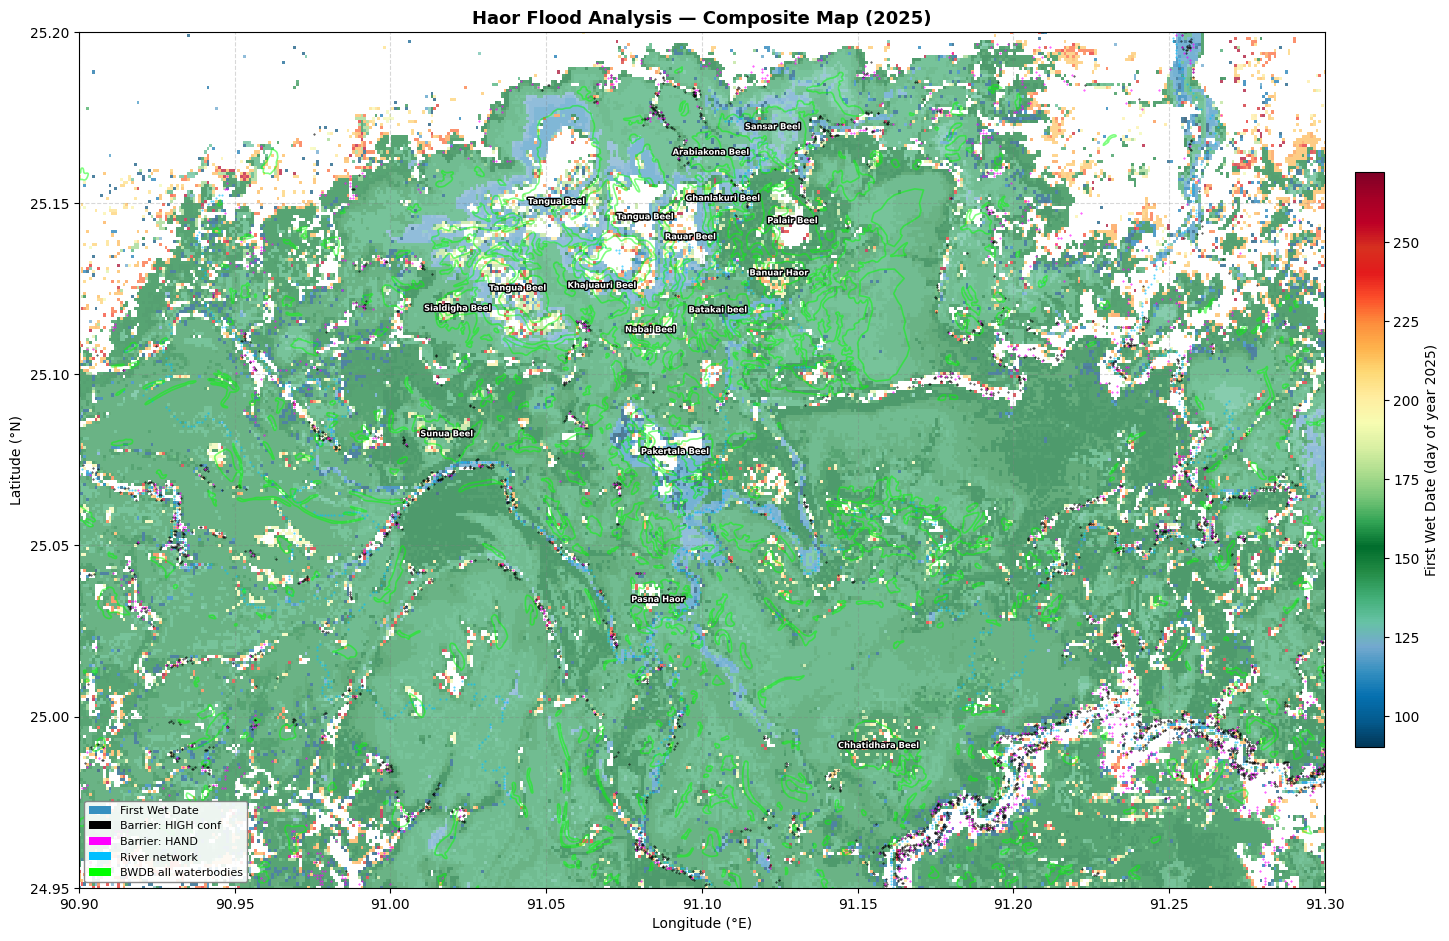

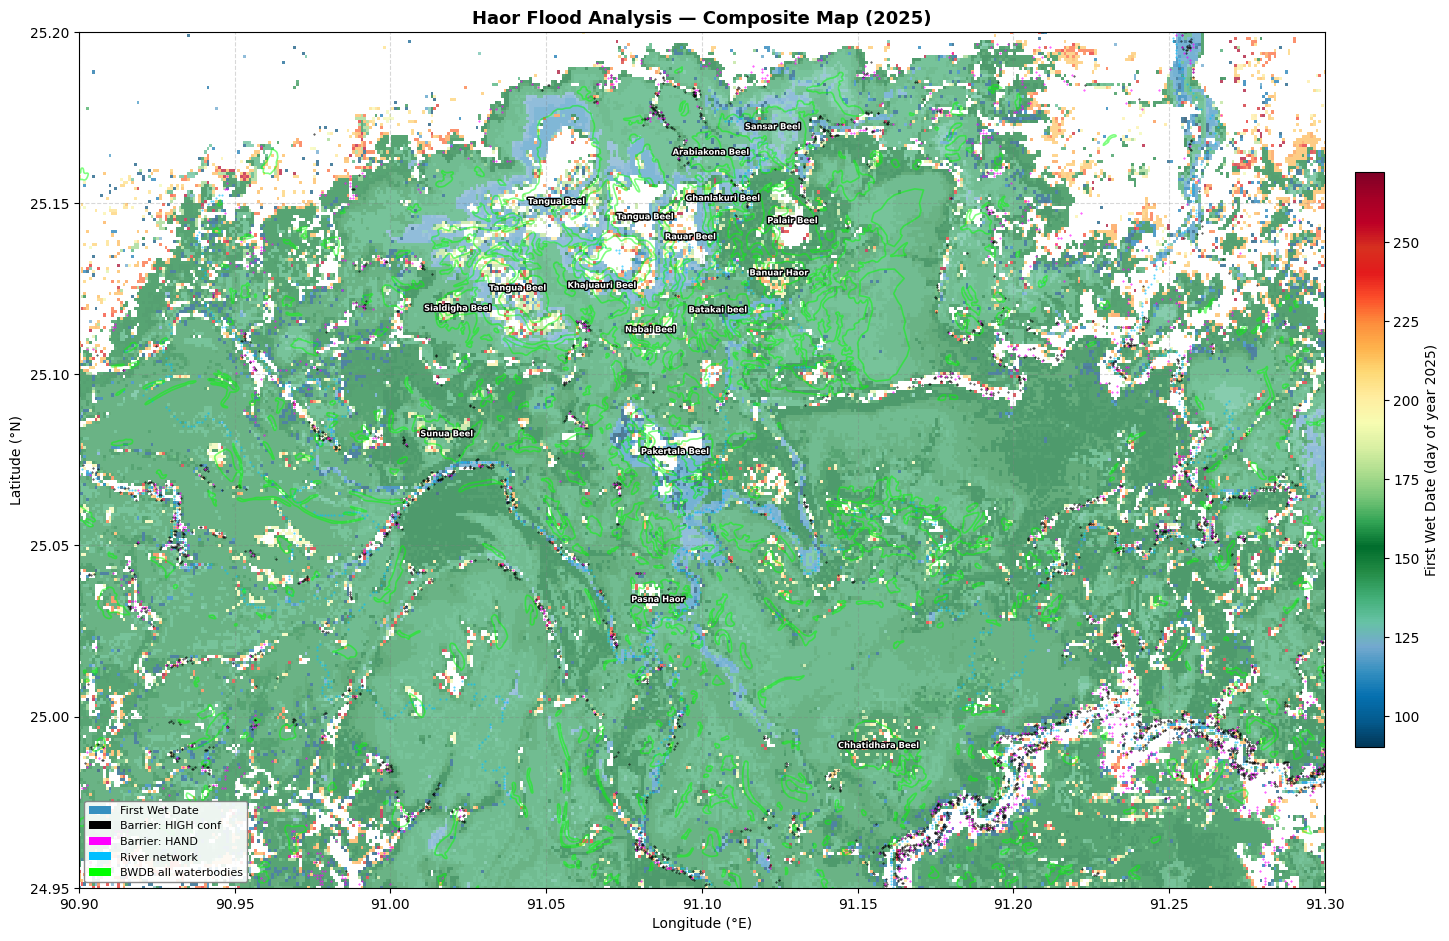

In [13]:
# %%
# =============================================================================
# CELL 10: ═══════ MASTER SETTINGS PANEL ═══════
# =============================================================================
# This is the section you edit and re-run to change the map.
# All data is already loaded in memory — re-running this cell is fast.
#
# To change the map:
#   1. Edit the values below
#   2. Re-run JUST THIS CELL (Shift+Enter)
#   3. New map appears
#
# Settings are organized by category for easy editing.
# =============================================================================

settings = {

    # ═══ MAP EXTENT (zoom) ═══
    # None = show full haor AOI
    # [west, east, south, north] = zoom into a specific area
    # Examples (uncomment one):
    #   "map_extent": None,                              # full extent
    #   "map_extent": [90.8, 91.5, 24.6, 25.2],          # Sunamganj area
    #   "map_extent": [91.0, 91.8, 24.5, 25.0],          # Tanguar/Dekhar
    #   "map_extent": [90.5, 91.2, 24.0, 24.6],          # Mymensingh haors
    #   "map_extent": [90.85,　91.50, 24.85, 25.25]      #Tanguar-Matian-Shanir Haor
    #   "map_extent": [91,　91.3, 25, 25.2]      #Tanguar-Matian-Shanir Haor smaller section
    #   "map_extent": [90.9,　91.3, 24.95, 25.2]      #Tanguar-Matian-Shanir Haor smaller section updated 
    
    "map_extent": [90.9, 91.3, 24.95, 25.2], 

    # ═══ FIGURE PROPERTIES ═══
    "figsize": (16, 10),
    "title": "Haor Flood Analysis — Composite Map (2025)",
    "dpi": 200,
    "save_filename": "composite_map.png",  # set to None to skip saving

    # ═══ LEGEND ═══
    "show_legend": True,
    "legend_loc": "lower left",
    "legend_fontsize": 8,

    # ═══════════════════════════════════════════════════════════════════
    # LAYER TOGGLES — set True to show, False to hide
    # ═══════════════════════════════════════════════════════════════════

    # --- Background rasters (drawn first, can stack with transparency) ---
    "show_first_wet_date":   True,   # Layer 1: flood propagation pattern
    "show_hand":             False,  # Layer 2: HAND values (continuous)
    "show_hand_classes":     False,  # Layer 3: HAND categorical (4 classes)
    "show_fabdem_relief":    False,  # Layer 4: FABDEM local relief (diverging)
    "show_fabdem_elev":      False,  # Layer 5: raw FABDEM elevation
    "show_jrc_water":        False,  # Layer 9: JRC historical water occurrence

    # --- Binary overlays (scatter points) ---
    "show_barriers_high":    True,   # Layer 5: HIGH-confidence barriers (magenta)
    "show_barriers_fabdem":  False,  # Layer 6: FABDEM-only barriers
    "show_barriers_hand":    True,  # HAND-only barriers
    "show_rivers":           True,  # Layer 7: river network

    # --- Boundary outlines ---
    "show_cocoah_haors":     False,  # Layer 8: CoCoAH detected haor outlines

    # ═══ BWDB WATERBODIES OVERLAY ═══
    "show_bwdb":             True,   # master switch for BWDB layer
    "bwdb_show_all":         True,  # show ALL 6686 waterbodies (cluttered!)
    "bwdb_show_haors":       False,   # show 49 named "Haor" features
    "bwdb_show_beels":       False,  # show 1132 named "Beel" features
    "bwdb_label_largest":    49,     # label top N largest by name (0 = no labels)

    # ═══════════════════════════════════════════════════════════════════
    # LAYER STYLING — colors, alphas, marker sizes
    # ═══════════════════════════════════════════════════════════════════

    # Alpha (transparency, 0-1): higher = more opaque
    "alpha_first_wet_date":  0.7,
    "alpha_hand":            0.7,
    "alpha_hand_classes":    0.7,
    "alpha_fabdem_relief":   0.7,
    "alpha_fabdem_elev":     0.7,
    "alpha_jrc_water":       0.6,
    "alpha_barriers_high":   1.0,
    "alpha_barriers_fabdem": 1.0,
    "alpha_barriers_hand":   1.0,
    "alpha_rivers":          0.7,
    "alpha_cocoah":          0.8,

    # Marker sizes for scatter overlays
    "marker_size_barriers":  0.15,
    "marker_size_rivers":    0.25,

    # Colors (hex codes)
    "color_barriers_high":   "000000",   # black
    "color_barriers_fabdem": "#FFFF00",  # yellow
    "color_barriers_hand":   "#FF00FF",  # magenta
    "color_rivers":          "#00BFFF",  # cyan blue
    "color_cocoah":          "#00FF00",  # bright green

    # BWDB styling
    "color_bwdb_all":        "#00FF00",  # cyan for all waterbodies
    "color_bwdb_haors":      "#00FF00",  # bright green for named haors
    "color_bwdb_beels":      "#00FF00",  # orange for named beels
    "lw_bwdb_all":           1.2,
    "lw_bwdb_haors":         1.2,
    "lw_bwdb_beels":         1.2,
}

# Render the map with current settings
render_map(settings)


In [12]:
# %%
# =============================================================================
# CELL 11: PRESET CONFIGURATIONS (re-run after Cell 10)
# =============================================================================
# Pre-made setting combinations for common analysis views.
# Copy any preset block into Cell 10 (or just call render_map with it).

# ---- PRESET 1: Flood propagation alone (clean view) ----
preset_propagation = dict(settings)  # Start from current settings
preset_propagation.update({
    "title": "Flood Propagation 2025 — First-Wet-Date Pattern",
    "save_filename": "preset_propagation.png",
    "show_first_wet_date": True,
    "show_barriers_high": False,
    "show_bwdb": True,
    "bwdb_show_all": False,
    "bwdb_show_haors": True,
    "bwdb_label_largest": 15,
})
# Uncomment to render: render_map(preset_propagation)

# ---- PRESET 2: Barriers + flood (your main thesis figure) ----
preset_thesis = dict(settings)
preset_thesis.update({
    "title": "Flood Propagation + Barriers — Connectivity Evidence",
    "save_filename": "preset_thesis_figure.png",
    "show_first_wet_date": True,
    "show_barriers_high": True,
    "show_cocoah_haors": False,
    "show_bwdb": True,
    "bwdb_show_haors": True,
    "bwdb_label_largest": 10,
    "alpha_first_wet_date": 0.7,
})
# Uncomment to render: render_map(preset_thesis)

# ---- PRESET 3: Terrain context only ----
preset_terrain = dict(settings)
preset_terrain.update({
    "title": "Haor Region Terrain Context",
    "save_filename": "preset_terrain.png",
    "show_first_wet_date": False,
    "show_hand": True,
    "show_barriers_high": True,
    "show_rivers": True,
    "show_bwdb": True,
    "bwdb_show_haors": True,
})
# Uncomment to render: render_map(preset_terrain)

# ---- PRESET 4: BWDB-only reference map ----
preset_bwdb_only = dict(settings)
preset_bwdb_only.update({
    "title": "BWDB Official Waterbodies (Reference)",
    "save_filename": "preset_bwdb_reference.png",
    "show_first_wet_date": False,
    "show_barriers_high": False,
    "show_bwdb": True,
    "bwdb_show_all": True,
    "bwdb_show_haors": True,
    "bwdb_show_beels": True,
    "bwdb_label_largest": 20,
})
# Uncomment to render: render_map(preset_bwdb_only)

# ---- PRESET 5: Zoom into Tanguar Haor area ----
preset_tanguar = dict(settings)
preset_tanguar.update({
    "title": "Tanguar Haor Area — Detailed View",
    "save_filename": "preset_tanguar.png",
    "map_extent": [91.0, 91.4, 24.95, 25.20],
    "show_first_wet_date": True,
    "show_barriers_high": True,
    "show_rivers": True,
    "show_bwdb": True,
    "bwdb_show_all": True,
    "bwdb_show_haors": True,
    "bwdb_show_beels": True,
    "bwdb_label_largest": 25,
    "marker_size_barriers": 0.5,  # bigger markers when zoomed in
    "lw_bwdb_all": 0.6,
})
# Uncomment to render: render_map(preset_tanguar)


print("""
═══════════════════════════════════════════════════════════════
PRESET CONFIGURATIONS AVAILABLE
═══════════════════════════════════════════════════════════════
  preset_propagation  - Clean flood propagation view
  preset_thesis       - Main thesis figure (flood + barriers)
  preset_terrain      - Terrain context (HAND + rivers + barriers)
  preset_bwdb_only    - BWDB reference map (all waterbodies)
  preset_tanguar      - Zoom into Tanguar Haor area

To render any preset:
  render_map(preset_propagation)
  render_map(preset_thesis)
  etc.

Or just edit the 'settings' dict in Cell 10 and re-run that cell.
═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
PRESET CONFIGURATIONS AVAILABLE
═══════════════════════════════════════════════════════════════
  preset_propagation  - Clean flood propagation view
  preset_thesis       - Main thesis figure (flood + barriers)
  preset_terrain      - Terrain context (HAND + rivers + barriers)
  preset_bwdb_only    - BWDB reference map (all waterbodies)
  preset_tanguar      - Zoom into Tanguar Haor area

To render any preset:
  render_map(preset_propagation)
  render_map(preset_thesis)
  etc.

Or just edit the 'settings' dict in Cell 10 and re-run that cell.
═══════════════════════════════════════════════════════════════

